In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

import pprint
import warnings

In [2]:
# import STlouis csv file
train = pd.read_csv('/Users/lydia22/Desktop/Group6/AACUW_Team6/Datasets/StLouis_ARPAExpenditures.csv')
#correct to your own path

In [3]:
df = train.copy()

In [4]:
df.head(5)

,ACCOUNT,AMOUNT,CENTER,CREDIT,DATE,DESC1,DESC2,DESC3,FUND,ID,ORACLEACCOUNT,ORACLECOSTCENTER,ORACLEFUND,ORACLEPROJECTNUMBER,ORDINANCE,PROJECTID,PROJECTTITLE,VENDOR
0,5647000,181.00,7007002,NaN,2021-08-30 00:00:00.0,V#503134 8/11/21 Parking,JE020434,,1170,1553666,5647000,700012,1509,100482,71393,42,Community Health Workers,JE020434
1,5636000,1164.37,7007002,NaN,2021-08-30 00:00:00.0,V#500024 7/12/21 Sprint,JE020434,,1170,1553582,5636000,700012,1509,100482,71393,42,Community Health Workers,JE020434
2,5636000,1164.67,7007002,NaN,2021-08-30 00:00:00.0,V#502218 8/2/21 Sprint,JE020434,,1170,1553587,5636000,700012,1509,100482,71393,42,Community Health Workers,JE020434
3,5237000,10195.00,7007007,NaN,2021-08-31 00:00:00.0,V505403,JE020473,,1170,1258623,5237000,700012,1509,100486,71393,47,COVID-19 Vaccination Incentive Program,JE020473
4,5237000,51540.00,7007007,NaN,2021-08-31 00:00:00.0,V504768,JE020474,,1170,1258631,5237000,700012,1509,100486,71393,47,COVID-19 Vaccination Incentive Program,JE020474


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10718 entries, 0 to 10717
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ACCOUNT              10718 non-null  int64  
 1   AMOUNT               10718 non-null  float64
 2   CENTER               10619 non-null  object 
 3   CREDIT               0 non-null      float64
 4   DATE                 10718 non-null  object 
 5   DESC1                5738 non-null   object 
 6   DESC2                5618 non-null   object 
 7   DESC3                5312 non-null   object 
 8   FUND                 10718 non-null  int64  
 9   ID                   10718 non-null  int64  
 10  ORACLEACCOUNT        10718 non-null  int64  
 11  ORACLECOSTCENTER     10718 non-null  int64  
 12  ORACLEFUND           10718 non-null  int64  
 13  ORACLEPROJECTNUMBER  10718 non-null  int64  
 14  ORDINANCE            10718 non-null  int64  
 15  PROJECTID            10718 non-null 

In [6]:
df['PROJECTTITLE'].value_counts()

Healthy Home Repair Program                                       3295
ACCOUNTING & LEGAL COMPLIANCE                                     1317
Community Health Workers                                          1055
Adult Education, Literacy and Skills Training                      588
Year Round Youth Jobs                                              443
                                                                  ... 
Vaccine Education and Marketing 71393: Communications Division       2
Comptroller Auditing Services                                        2
United Way Programmed Coordination-Targeted Cash Assistance          1
Wrap Around Services                                                 1
Gateway Go (Bi-State)                                                1
Name: PROJECTTITLE, Length: 104, dtype: int64

In [7]:
# time series analysis: date vs amount 
df['DATE'] = pd.to_datetime(df['DATE']) #change to the datetime 
df_time_series = df.groupby('DATE')['AMOUNT'].sum().reset_index()
#groupby function with the df, group by Date, sum up the amount and reset the index of the date
df_time_series.head(5)

,DATE,AMOUNT
0,2021-08-30,2510.04
1,2021-08-31,61735.00
2,2021-09-01,68.00
3,2021-09-03,3523.45
4,2021-09-13,259.76


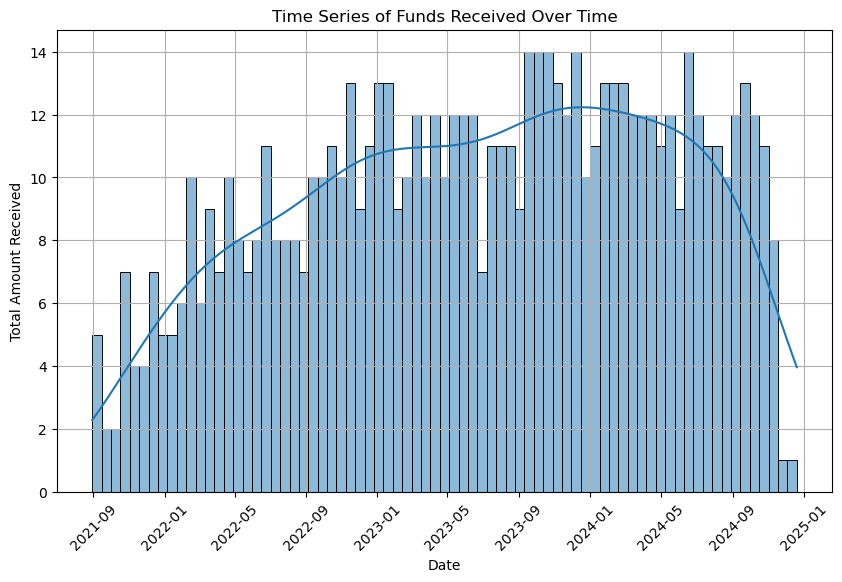

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(df_time_series['DATE'], bins=75, kde=True)

plt.xlabel("Date")
plt.ylabel("Total Amount Received")
plt.title("Time Series of Funds Received Over Time")
plt.xticks(rotation=45)  
plt.grid(True)

plt.show()


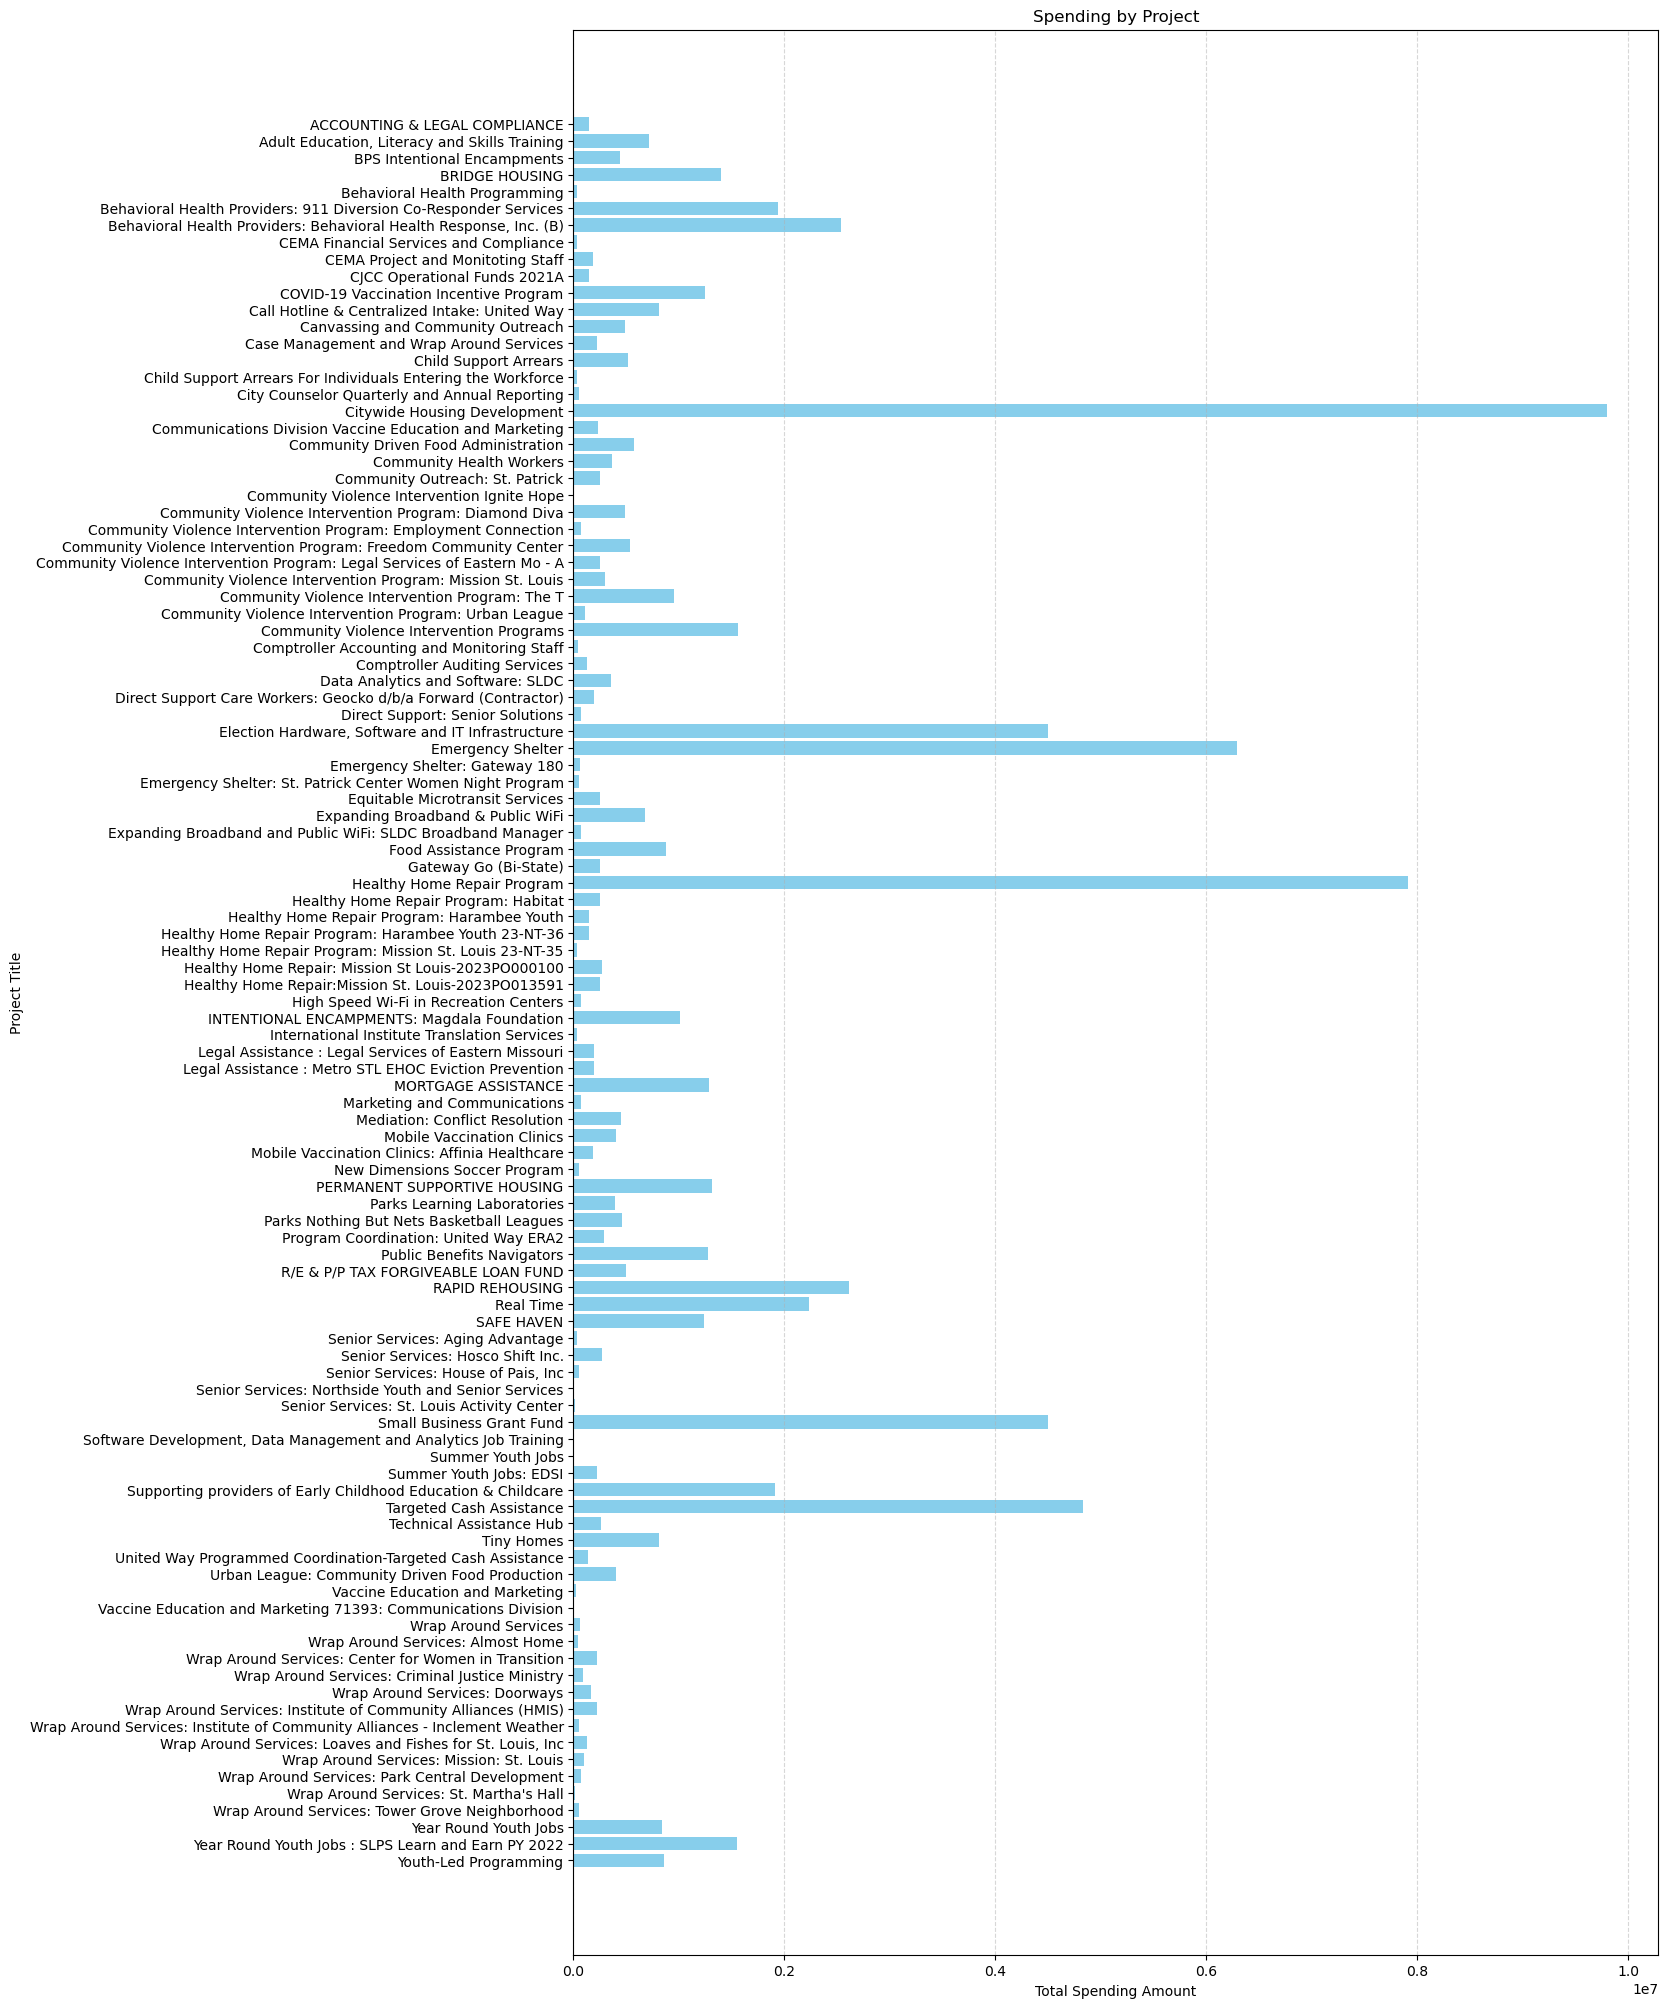

In [9]:
# Spending by Project: projectile vs amount 
df_selected = df[['PROJECTTITLE','AMOUNT']]
df_project = df_selected.groupby('PROJECTTITLE')['AMOUNT'].sum().reset_index()
#df_project = df_project.sort_values(by='AMOUNT', ascending=False) arrange with order

plt.figure(figsize=(14,25))

# bar plot
plt.barh(df_project['PROJECTTITLE'], df_project['AMOUNT'], color='skyblue')
plt.xlabel("Total Spending Amount")
plt.ylabel("Project Title")
plt.title("Spending by Project")
plt.gca().invert_yaxis()  # Invert to show highest spending at the top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()